## load allthebacteria metadata (what seems to be the most interesting file for now)

In [1]:
import pandas as pd
from pathlib import Path


MD_PATH = Path("/home/cyrille/dev/microtaxo/data/metadata")


# content = MD_PATH / "assembly-stats.decontam.tsv"
content = MD_PATH / "ena_metadata.tsv"
df = pd.read_csv(content, sep="\t")
df

/tmp/ipykernel_380871/3982220849.py:10: DtypeWarning: Columns (5,6,8,9,10,11,12,13,14,15,20,21,22,25,26,27,28,30,31,36,39,41,42,46,47,48,51,52,55,56,58,59,60,62,63,64,66,68,69,70,72,73,77,79,80,83,89,90,91,92,99,100,102,103,112,115,116) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(content, sep="\t")


,sample_accession,run_accession,submission_accession,assembly_software,library_selection,serotype,environment_feature,last_updated,submitted_galaxy,germline,...,taxonomic_classification,protocol_label,elevation,salinity,sequencing_method,first_public,study_alias,ph,tissue_type,isolation_source
0,SAMD00008604,DRR008449,DRA000969,NaN,RANDOM,NaN,NaN,2015-06-19,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2014-04-28,DRP001007,NaN,NaN,NaN
1,SAMD00002817,DRR016177,DRA001721,NaN,size fractionation,NaN,NaN,2018-10-02,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2018-10-02,PRJDB1847,NaN,NaN,NaN
2,SAMD00019027,DRR021788,DRA002419,NaN,RANDOM,NaN,NaN,2017-10-21,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2017-10-21,PRJDB2736,NaN,NaN,NaN
3,SAMD00019237,DRR022206,DRA002431,NaN,RANDOM,NaN,NaN,2021-12-28,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2021-12-28,DRP008013,NaN,NaN,NaN
4,SAMD00019241,DRR022210,DRA002431,NaN,RANDOM,NaN,NaN,2021-12-28,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2021-12-28,DRP008013,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1943488,SAMN10405967,SRR8179222,SRA808114,NaN,RANDOM,Heidelberg,NaN,2018-11-10,NaN,False,...,NaN,NaN,NaN,NaN,NaN,2018-11-10,PRJNA242847,NaN,NaN,comminuted beef
1943489,SAMN10405968,SRR8179219,SRA808111,NaN,RANDOM,Anatum,NaN,2018-11-10,NaN,False,...,NaN,NaN,NaN,NaN,NaN,2018-11-10,PRJNA242847,NaN,NaN,comminuted beef
1943490,SAMN10407504,SRR8180444,SRA808182,NaN,RANDOM,not typed,NaN,2018-11-10,NaN,False,...,NaN,NaN,NaN,NaN,NaN,2018-11-10,PRJNA212117,NaN,NaN,blood
1943491,SAMN10407505,SRR8180405,SRA808181,NaN,RANDOM,not typed,NaN,2018-11-10,NaN,False,...,NaN,NaN,NaN,NaN,NaN,2018-11-10,PRJNA212117,NaN,NaN,placenta


## check columns names/values

In [2]:
df.iloc[0].to_dict()

{'sample_accession': 'SAMD00008604',
 'run_accession': 'DRR008449',
 'submission_accession': 'DRA000969',
 'assembly_software': nan,
 'library_selection': 'RANDOM',
 'serotype': nan,
 'environment_feature': nan,
 'last_updated': '2015-06-19',
 'submitted_galaxy': nan,
 'germline': nan,
 'culture_collection': nan,
 'submission_tool': nan,
 'sra_bytes': 130004514.0,
 'collected_by': nan,
 'submitted_ftp': nan,
 'isolate': nan,
 'fastq_bytes': '132346864;79650546',
 'instrument_platform': 'ILLUMINA',
 'variety': nan,
 'temperature': nan,
 'sra_aspera': 'fasp.sra.ebi.ac.uk:/vol1/drr/DRR008/DRR008449',
 'ecotype': nan,
 'submitted_aspera': nan,
 'sampling_campaign': nan,
 'tissue_lib': nan,
 'environmental_sample': nan,
 'sex': nan,
 'submitted_md5': nan,
 'checklist': nan,
 'fastq_galaxy': 'ftp.sra.ebi.ac.uk/vol1/fastq/DRR008/DRR008449/DRR008449_1.fastq.gz;ftp.sra.ebi.ac.uk/vol1/fastq/DRR008/DRR008449/DRR008449_2.fastq.gz',
 'specimen_voucher': nan,
 'submitted_bytes': nan,
 'taxonomic_ide

## basic exploration

In [3]:
len(df.columns)

118

In [4]:
# nothing there
df["taxonomic_classification"].unique()

array([nan])

In [5]:
# nothing there
df["taxonomic_identity_marker"].unique()

array([nan])

In [6]:
# looks interesting
df["tax_id"].unique()

array([224308.0, 1280.0, 562.0, ..., 2486975, 2486976, 2486977],
      dtype=object)

In [7]:
# we can use it later, too
df["scientific_name"].unique()

array(['Bacillus subtilis subsp. subtilis str. 168',
       'Staphylococcus aureus', 'Escherichia coli', ...,
       'Campylobacter sp. OH-18-19611-1',
       'Campylobacter sp. OH-18-19102-CU',
       'Campylobacter sp. OH-18-15554-1'], dtype=object)

## populate API cache

In [8]:
from urllib.error import HTTPError
from Bio import Entrez
from diskcache import Cache
from tqdm.auto import tqdm

Entrez.email = "cyrille.leroux@irisa.fr"
CACHE_DIR = "/data/microtaxo/apicache"
cache = Cache(CACHE_DIR)

# ~4-5h without API key
errors = list()
unique_tax_ids = list()

def get_api_data(tax_id):
    # error: not a number / None
    if pd.isna(tax_id):
        errors.append(tax_id)
        return None      
    
    # float/string -> int
    try:        
        tax_id = int(tax_id)
    except ValueError:
        errors.append(tax_id)
        return None
    
    # hit cache
    if tax_id in cache:
        unique_tax_ids.append(tax_id)
        return cache[tax_id]
    
     # API call + cache
    try:
        handle = Entrez.efetch(db="taxonomy", id=str(tax_id), retmode="xml")
        records = Entrez.read(handle)
        cache[tax_id] = records
        unique_tax_ids.append(tax_id)
        return records
    except HTTPError:
        errors.append(tax_id)

    return None

    


for tax_id in tqdm(df["tax_id"].unique()):
    get_api_data(tax_id)




/home/cyrille/.cache/pypoetry/virtualenvs/microtaxo-SPpTyrCZ-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 38659/38659 [00:01<00:00, 22801.99it/s]


In [9]:
# extra tax_id
extra_tax_ids = set()
for tax_id in tqdm(unique_tax_ids):
    if tax_id in cache:
        if tdata := cache[tax_id]:
            extra_tax_ids.update([int(lin["TaxId"]) for lin in tdata[0].get("LineageEx", {})])
for tax_id in tqdm(extra_tax_ids):
    get_api_data(tax_id)
extra_tax_ids = list(extra_tax_ids)


100%|██████████| 6566/6566 [00:00<00:00, 19557.71it/s]


### let's see what wrong with rejected tax_ids

In [10]:
# it looks like multiple values in single field: we may or may not do something about it later
len(errors), len(unique_tax_ids), len(extra_tax_ids), errors

(148,
 45077,
 6566,
 [nan,
  '54736,33035',
  '33035,83558',
  '1313,561276',
  '561276,1313',
  '28449,486',
  '34026,486',
  '34026,488',
  '488,1906581',
  '33053,488',
  '267212,488',
  '486,495',
  '488,28449',
  '488,28091',
  '488,267212',
  '33053,486',
  '483,486',
  '28449,490',
  '28449,488',
  '482,486',
  '194197,486',
  '489,28449',
  '28449,34026',
  '28449,33053',
  '488,486',
  '493,486',
  '488,483',
  '489,483',
  '28449,483',
  '90368,483',
  '483,489',
  '727,726',
  '729,727',
  '727,729',
  '729,726',
  '726,729',
  '119912,57046',
  '119912,590',
  '41529,119912',
  '41529,590',
  '57046,119912',
  '590,41529',
  '273136,813',
  '813,273136',
  '149539,98360',
  '98360,149539',
  '1781,1806',
  '1806,1781',
  '1773,33894',
  '33894,1773',
  '1765,1773',
  '818,823',
  '823,821',
  '363265,823',
  '29485,33060',
  '33060,29485',
  '631,633',
  '633,631',
  '633,29484',
  '633,33060',
  '29486,633',
  '630,633',
  '633,28152',
  '631,29484',
  '29485,29484',
  '6

In [11]:
from pprint import pprint
# visualize first entry (check what's available)
tax_id = list(cache)[0]
pprint(dict(cache[tax_id][0]))

{'CreateDate': '2002/05/08 12:00:00',
 'Division': 'Bacteria',
 'GeneticCode': {'GCId': '11', 'GCName': 'Bacterial, Archaeal and Plant Plastid'},
 'Lineage': 'cellular organisms; Bacteria; Bacillati; Bacillota; Bacilli; Bacillales; Bacillaceae; Bacillus; Bacillus subtilis group; Bacillus subtilis; Bacillus subtilis subsp. subtilis',
 'LineageEx': [{'TaxId': '131567', 'ScientificName': 'cellular organisms', 'Rank': 'no rank'}, {'TaxId': '2', 'ScientificName': 'Bacteria', 'Rank': 'superkingdom'}, {'TaxId': '1783272', 'ScientificName': 'Bacillati', 'Rank': 'kingdom'}, {'TaxId': '1239', 'ScientificName': 'Bacillota', 'Rank': 'phylum'}, {'TaxId': '91061', 'ScientificName': 'Bacilli', 'Rank': 'class'}, {'TaxId': '1385', 'ScientificName': 'Bacillales', 'Rank': 'order'}, {'TaxId': '186817', 'ScientificName': 'Bacillaceae', 'Rank': 'family'}, {'TaxId': '1386', 'ScientificName': 'Bacillus', 'Rank': 'genus'}, {'TaxId': '653685', 'ScientificName': 'Bacillus subtilis group', 'Rank': 'species group'

# exploration + compute some stats

In [12]:
# before stats: cache -> dict + convertion (easier to handle)
data = {tax_id: dict(cache[tax_id][0]) for tax_id in unique_tax_ids + extra_tax_ids if cache[tax_id]}
print(len(data))  # only valid entries
# sample
pprint(data[367830])

42924
{'CreateDate': '2006/01/23 11:41:48',
 'Division': 'Bacteria',
 'GeneticCode': {'GCId': '11', 'GCName': 'Bacterial, Archaeal and Plant Plastid'},
 'Lineage': 'cellular organisms; Bacteria; Bacillati; Bacillota; Bacilli; Bacillales; Staphylococcaceae; Staphylococcus; Staphylococcus aureus',
 'LineageEx': [{'TaxId': '131567', 'ScientificName': 'cellular organisms', 'Rank': 'no rank'}, {'TaxId': '2', 'ScientificName': 'Bacteria', 'Rank': 'superkingdom'}, {'TaxId': '1783272', 'ScientificName': 'Bacillati', 'Rank': 'kingdom'}, {'TaxId': '1239', 'ScientificName': 'Bacillota', 'Rank': 'phylum'}, {'TaxId': '91061', 'ScientificName': 'Bacilli', 'Rank': 'class'}, {'TaxId': '1385', 'ScientificName': 'Bacillales', 'Rank': 'order'}, {'TaxId': '90964', 'ScientificName': 'Staphylococcaceae', 'Rank': 'family'}, {'TaxId': '1279', 'ScientificName': 'Staphylococcus', 'Rank': 'genus'}, {'TaxId': '1280', 'ScientificName': 'Staphylococcus aureus', 'Rank': 'species'}],
 'MitoGeneticCode': {'MGCId': '0'

## check content

In [13]:
# available ranks
ranks = set()
for values in tqdm(data.values()):
    if values:
        for le in values.get("LineageEx", {}):
            if le:
                ranks.add(le["Rank"])
ranks

100%|██████████| 42924/42924 [00:00<00:00, 430045.28it/s]


{'biotype',
 'clade',
 'class',
 'family',
 'genus',
 'kingdom',
 'no rank',
 'order',
 'pathogroup',
 'phylum',
 'serogroup',
 'serotype',
 'species',
 'species group',
 'species subgroup',
 'strain',
 'subclass',
 'subfamily',
 'subgenus',
 'suborder',
 'subspecies',
 'superkingdom',
 'tribe'}

In [16]:
# interesting sample (contains rare rank)
data[561275]

{'TaxId': '561275',
 'ScientificName': 'Mycobacterium tuberculosis variant bovis BCG str. Tokyo 172',
 'OtherNames': {'Misnomer': [], 'Teleomorph': [], 'Synonym': ['Mycobacterium bovis BCG str. Tokyo 172'], 'Acronym': [], 'Anamorph': [], 'EquivalentName': ['Mycobacterium bovis BCG Tokyo 172', 'Mycobacterium bovis BCG strain Tokyo 172'], 'GenbankAnamorph': [], 'CommonName': [], 'Name': [], 'GenbankSynonym': [], 'Misspelling': [], 'Includes': [], 'Inpart': []},
 'ParentTaxId': '33892',
 'Rank': 'strain',
 'Division': 'Bacteria',
 'GeneticCode': {'GCId': '11', 'GCName': 'Bacterial, Archaeal and Plant Plastid'},
 'MitoGeneticCode': {'MGCId': '0', 'MGCName': 'Unspecified'},
 'Lineage': 'cellular organisms; Bacteria; Bacillati; Actinomycetota; Actinomycetes; Mycobacteriales; Mycobacteriaceae; Mycobacterium; Mycobacterium tuberculosis complex; Mycobacterium tuberculosis; Mycobacterium tuberculosis variant bovis; Mycobacterium tuberculosis variant bovis BCG',
 'LineageEx': [{'TaxId': '131567',

## get all valid tax_id in dataframe

In [18]:

def clean_tax_id(tax_id):   
    try:        
        return int(tax_id)
    except ValueError:
        return None
    
tax_ids = df["tax_id"].apply(clean_tax_id).dropna().astype(int).to_list()
len(tax_ids)


1943014

## count by rank

In [76]:
from collections import defaultdict
import pandas as pd

linstats = defaultdict(int)
skipped = list()
for tax_id in tqdm(tax_ids):
    if tax_id not in data:
        skipped.append(tax_id)
        continue
    parent_tax_id = int(data[tax_id]["ParentTaxId"])
    linstats[tax_id] += 1
    for lin in data[tax_id]["LineageEx"]:
        lin_tax_id = int(lin["TaxId"])
        linstats[lin_tax_id] += 1
        if lin_tax_id == parent_tax_id:
            break
dfcount = pd.DataFrame.from_dict(linstats, orient="index", columns=["count"]).sort_values("count", ascending=False)
linstats = dict(linstats) # avoid future key creations
len(linstats), len(skipped)


100%|██████████| 1943014/1943014 [00:03<00:00, 512806.84it/s]


(42935, 1622)

In [23]:
# export file : dfcount.xlsx

def get_attr(tax_id, attr):
    tax_id = int(tax_id)
    if tax_id in data:
        return data[tax_id].get(attr, "")
    return ""
dfcount["name"] = dfcount.index.map(lambda tax_id: get_attr(tax_id, "ScientificName"))
dfcount["rank"] = dfcount.index.map(lambda tax_id: get_attr(tax_id, "Rank"))
dfcount.to_excel("out/dfcount.xlsx")
dfcount

,count,name,rank
131567,1941392,cellular organisms,no rank
2,1941392,Bacteria,superkingdom
3379134,1316225,Pseudomonadati,kingdom
1224,1184792,Pseudomonadota,phylum
1236,1073702,Gammaproteobacteria,class
...,...,...,...
2485257,1,Salmonella sp. HC-285,species
2485255,1,Salmonella sp. MA2-181,species
2485254,1,Salmonella sp. MA3-182,species
2485250,1,Salmonella sp. ZA-271,species


## families only

In [24]:
len(dfcount[dfcount["rank"] == "family"])

516

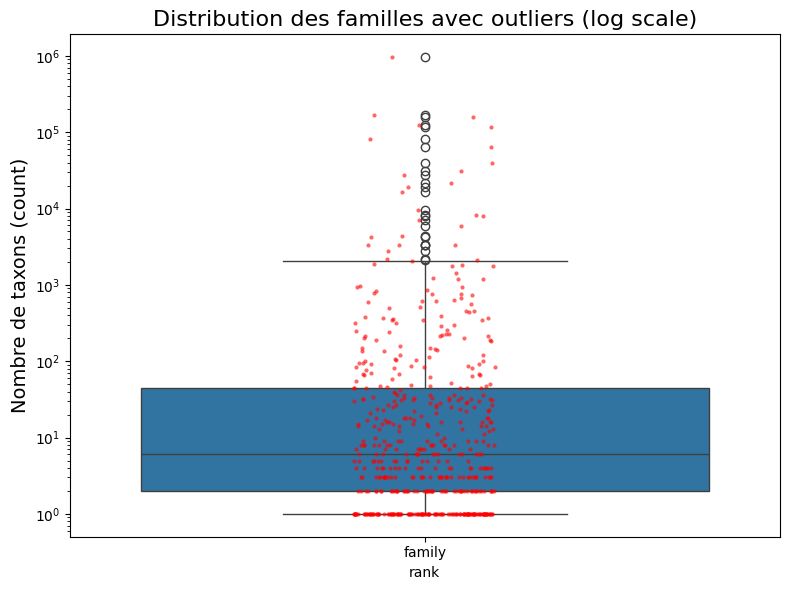

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
df_sorted = dfcount[dfcount["rank"] == "family"]

plt.figure(figsize=(8, 6))
sns.boxplot(x='rank', y='count', data=df_sorted, whis=[5, 95])
sns.stripplot(x='rank', y='count', data=df_sorted, size=3, alpha=0.6, jitter=True, color='red')
plt.yscale('log')
plt.title('Distribution des familles avec outliers (log scale)', fontsize=16)
plt.ylabel('Nombre de taxons (count)', fontsize=14)
plt.tight_layout()
plt.show()


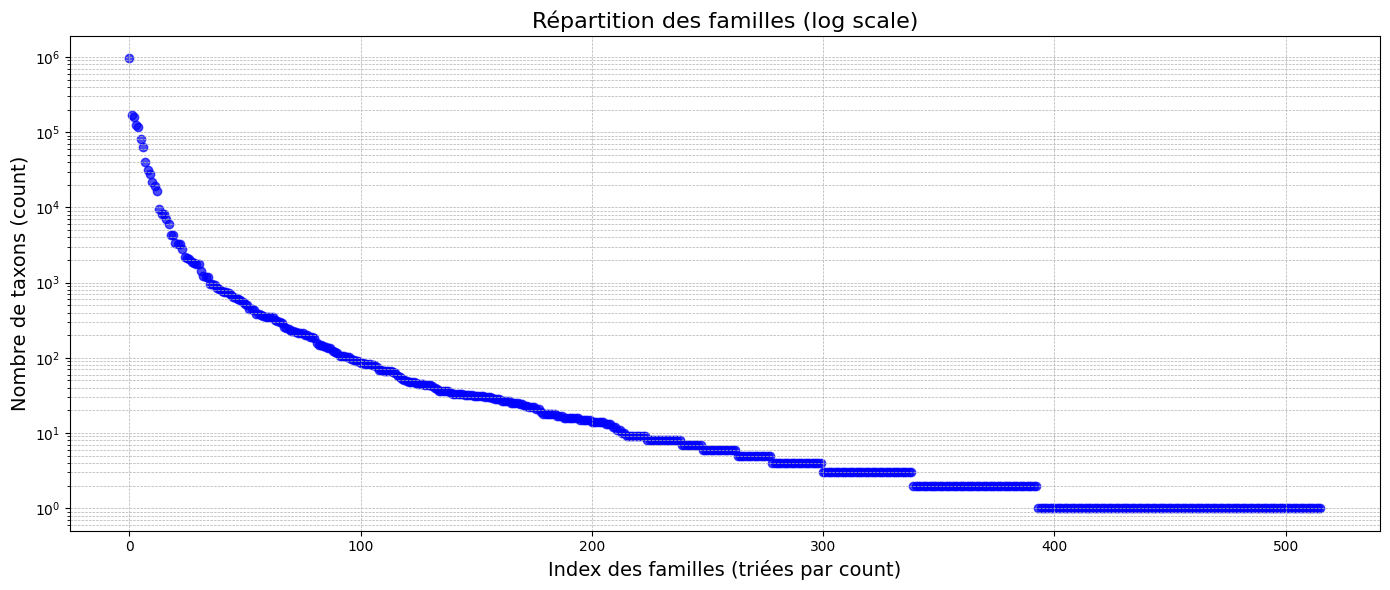

In [26]:
plt.figure(figsize=(14, 6))
plt.scatter(range(len(df_sorted)), df_sorted['count'], alpha=0.7, c='blue')
plt.yscale('log')
plt.title('Répartition des familles (log scale)', fontsize=16)
plt.xlabel('Index des familles (triées par count)', fontsize=14)
plt.ylabel('Nombre de taxons (count)', fontsize=14)
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## graph

In [51]:
# data
# linstats
# unique_tax_ids

import networkx as nx
G = nx.DiGraph()
# nodes
for tax_id in tqdm(set(unique_tax_ids + extra_tax_ids)):
    if tax_id in data:
        tdata = data[tax_id]
        G.add_node(tax_id, name=tdata["ScientificName"], count=linstats[tax_id], rank=tdata["Rank"])

# edges
for tax_id in tqdm(set(unique_tax_ids)):
    if tax_id in data:
        tdata = data[tax_id]
        lineage = tdata.get("LineageEx", [])
        for i in range(len(lineage) - 1):
            parent = lineage[i]
            child = lineage[i + 1]
            # node = G.nodes[tax_id]
            G.add_edge(int(parent["TaxId"]), int(child["TaxId"]) )


# example
G.nodes[1969992]

# way to large...

# plt.figure(figsize=(12, 12))
# pos = nx.spring_layout(G, k=0.5, iterations=50)
# nx.draw(
#     G,
#     pos,
#     with_labels=False,
#     node_size=500,
#     node_color='lightblue',
#     edge_color='gray',
#     alpha=0.8
# )

# node_labels = {node: G.nodes[node]['name'] for node in G.nodes if 'name' in G.nodes[node]}
# nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)

# plt.title("Hiérarchie taxonomique", fontsize=16)
# plt.show()

100%|██████████| 43019/43019 [00:00<00:00, 113542.11it/s]


{'name': 'Desertifilaceae', 'count': 2, 'rank': 'family'}

## performance issue : remove all nodes under "family" rank
(graph.html will still take a few minutes to load)

In [52]:
family_nodes = [node for node, attrs in G.nodes(data=True) if attrs.get("rank") == "family"]

Gfam = G.copy()
descendants_to_remove = set()
for family_node in family_nodes:
    descendants_to_remove.update(nx.descendants(Gfam, family_node))
Gfam.remove_nodes_from(descendants_to_remove)

In [48]:
# family_nodes[0], G.edges(family_nodes[0])
len([node for node, attrs in G.nodes(data=True) if attrs.get("rank") == "strain"])

15866

/home/cyrille/.cache/pypoetry/virtualenvs/microtaxo-SPpTyrCZ-py3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


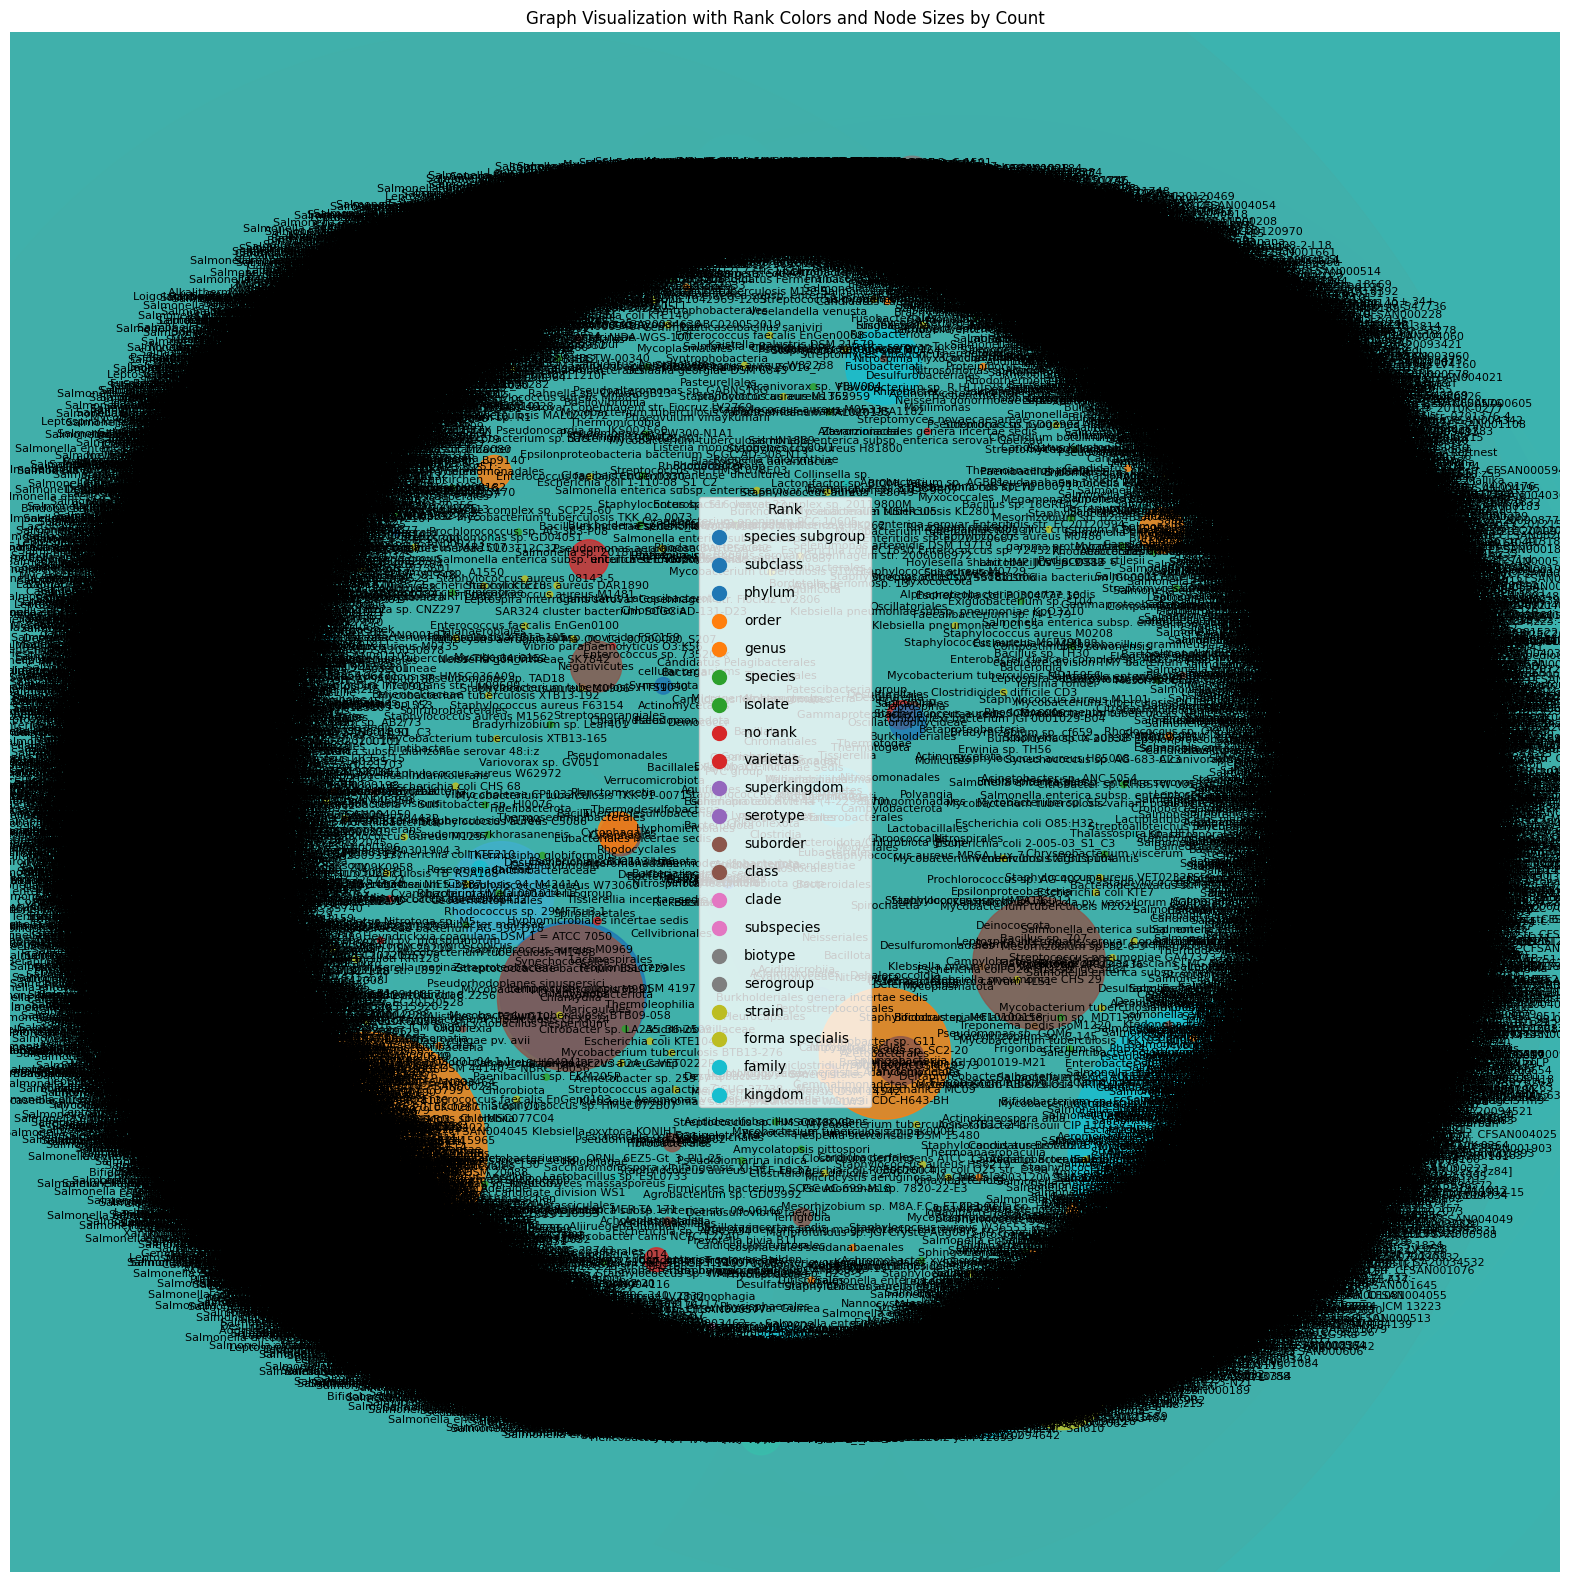

In [36]:
# --> 30mn to generate unusable plot

# import matplotlib.pyplot as plt
# import networkx as nx

# import matplotlib.cm as cm

# ranks = list(set(nx.get_node_attributes(G, "rank").values()))
# rank_to_color = {rank: cm.tab10(i / len(ranks)) for i, rank in enumerate(ranks)}
# node_colors = [rank_to_color[G.nodes[node]["rank"]] for node in G.nodes]
# node_sizes = [max(20, G.nodes[node]["count"] * 5) for node in G.nodes]
# node_labels = {node: G.nodes[node]["name"] for node in G.nodes}

# pos = nx.spring_layout(G, seed=42)

# plt.figure(figsize=(20, 20))
# nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8)
# nx.draw_networkx_edges(G, pos, alpha=0.3)
# nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_color="black")

# for rank, color in rank_to_color.items():
#     plt.scatter([], [], c=[color], label=rank, s=100)
# plt.legend(scatterpoints=1, frameon=True, labelspacing=1, title="Rank")

# plt.title("Graph Visualization with Rank Colors and Node Sizes by Count")
# plt.axis("off")
# plt.show()

## tool for visualizing nodes

out/graph.html


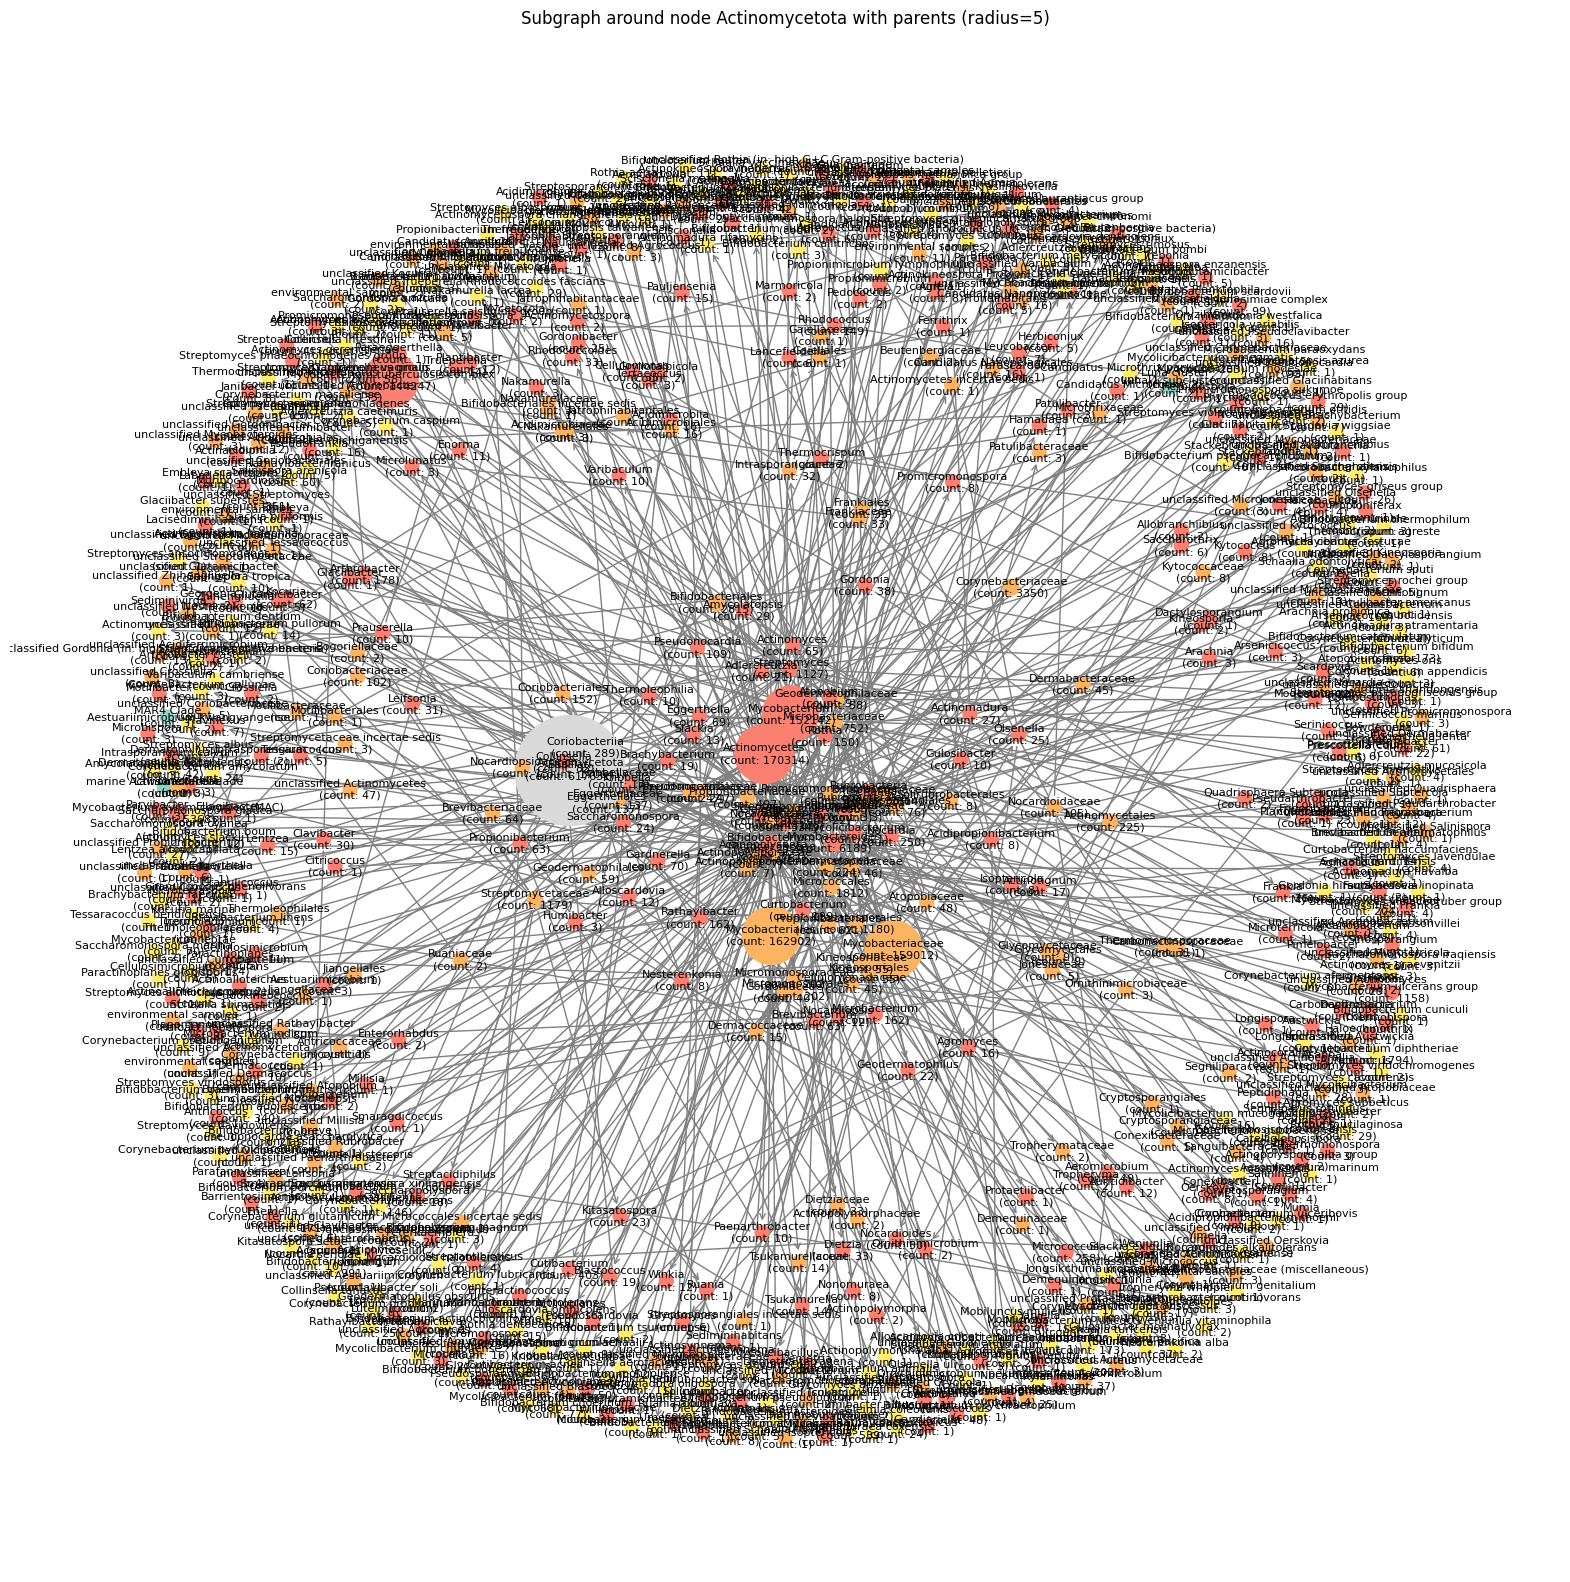

In [125]:
from pyvis.network import Network

def visualize_node(G, tax_id, radius=1, figsize=(10, 10), output="out/graph.html"):

    subgraph_nodes = set(nx.ego_graph(G, tax_id, radius=radius).nodes)
    
    for node in list(subgraph_nodes):
        subgraph_nodes.update(G.predecessors(node))
    
    subgraph = G.subgraph(subgraph_nodes)

    pos = nx.spring_layout(subgraph)

    node_sizes = [100 + subgraph.nodes[n].get('count', 1) / 100 for n in subgraph.nodes()]
    node_colors = [hash(subgraph.nodes[n].get('rank', '-')) % 10 for n in subgraph.nodes()]

    labels = {
        n: f"{subgraph.nodes[n].get('name', '-')}\n(count: {subgraph.nodes[n].get('count', '-')})"
        for n in subgraph.nodes()
    }

    # interactive
    if output:
        net = Network(notebook=True)
        net.from_nx(subgraph)

        for node in subgraph.nodes():
            node_data = subgraph.nodes[node]
            label = f"{node_data.get('name', '-')} (count: {node_data.get('count', 1)})"
            
            rank = node_data.get('rank', '-')
            if rank == "family":
                color = 'lightblue'
            elif rank == "genus":
                color = 'lightgreen'
            elif rank == "species":
                color = 'lightyellow'
            elif rank == "order":
                color = 'lightcoral'
            else:
                color = 'lightgray'

            net.get_node(node)['label'] = label
            net.get_node(node)['color'] = color
            net.get_node(node)['size'] = max(5, node_data.get('count', 1) /10000)
                    

        net.show(output)

    # image

    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(
        subgraph,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=plt.cm.Set3,
    )
    nx.draw_networkx_edges(
        subgraph,
        pos,
        arrowstyle="->",
        arrowsize=10,
        edge_color="gray",
    )
    nx.draw_networkx_labels(
        subgraph,
        pos,
        labels=labels,
        font_size=8,
    )

    plt.title(f"Subgraph around node {data[tax_id]['ScientificName']} with parents (radius={radius})")
    plt.axis("off")
    plt.show()

# visualize_node(G, 543, 2)
# visualize_node(G, 506, radius=5, figsize=(20, 20))
visualize_node(G, 201174, radius=5, figsize=(20, 20))
